11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


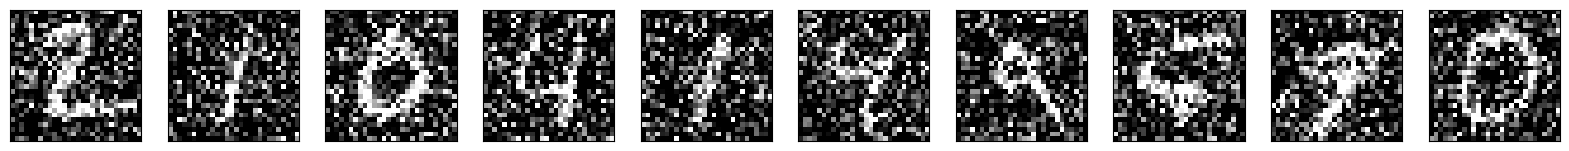

Epoch 1/3
469/469 ━━━━━━━━━━━━━━━━━━━━ 68s 143ms/step - loss: 0.1658 - val_loss: 0.1157
Epoch 2/3
469/469 ━━━━━━━━━━━━━━━━━━━━ 66s 140ms/step - loss: 0.1123 - val_loss: 0.1081
Epoch 3/3
469/469 ━━━━━━━━━━━━━━━━━━━━ 82s 140ms/step - loss: 0.1067 - val_loss: 0.1038
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step


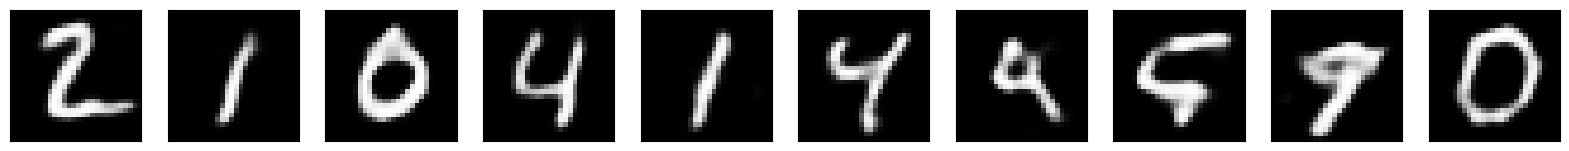

In [13]:
import keras
from keras.datasets import mnist
from keras import layers
import numpy as np
from keras.callbacks import TensorBoard
import matplotlib.pyplot as plt

# Load MNIST dataset
(X_train, _), (X_test, _) = mnist.load_data()

# Normalize data
X_train = X_train.astype('float32') / 255.
X_test = X_test.astype('float32') / 255.

# Reshape to (28, 28, 1) for Conv2D input
X_train = np.reshape(X_train, (len(X_train), 28, 28, 1))
X_test = np.reshape(X_test, (len(X_test), 28, 28, 1))

# Add random noise to the images
noise_factor = 0.5
X_train_noisy = X_train + noise_factor * np.random.normal(
    loc=0.0, scale=1.0, size=X_train.shape
)
X_test_noisy = X_test + noise_factor * np.random.normal(
    loc=0.0, scale=1.0, size=X_test.shape
)

# Clip values to be between 0 and 1
X_train_noisy = np.clip(X_train_noisy, 0., 1.)
X_test_noisy = np.clip(X_test_noisy, 0., 1.)

# Show noisy images
n = 10
plt.figure(figsize=(20, 2))
for i in range(1, n + 1):
    ax = plt.subplot(1, n, i)
    plt.imshow(X_test_noisy[i].reshape(28, 28), cmap='gray')
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
plt.show()

# Build Autoencoder Model
input_img = keras.Input(shape=(28, 28, 1))

# Encoder
x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(input_img)
x = layers.MaxPooling2D((2, 2), padding='same')(x)
x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(x)
encoded = layers.MaxPooling2D((2, 2), padding='same')(x)

# Decoder
x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(encoded)
x = layers.UpSampling2D((2, 2))(x)
x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(x)
x = layers.UpSampling2D((2, 2))(x)
decoded = layers.Conv2D(1, (3, 3), activation='sigmoid', padding='same')(x)

# Compile model
autoencoder = keras.Model(input_img, decoded)
autoencoder.compile(optimizer='adam', loss='binary_crossentropy')

# Train model
autoencoder.fit(
    X_train_noisy,
    X_train,
    epochs=3,
    batch_size=128,
    shuffle=True,
    validation_data=(X_test_noisy, X_test),
    callbacks=[TensorBoard(log_dir='/tmp/tb', histogram_freq=0, write_graph=False)]
)

# Predict (denoise)
predictions = autoencoder.predict(X_test_noisy)

# Show reconstructed images
m = 10
plt.figure(figsize=(20, 2))
for i in range(1, m + 1):
    ax = plt.subplot(1, m, i)
    plt.imshow(predictions[i].reshape(28, 28), cmap='gray')
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
plt.show()